# День 08. Упражнение 00 
# Бинарный классификатор. Логистическая регрессия

## 0. Импорты

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

## 1. Предобработка

- Получи данные из файла [`checker-timestamp.csv`](https://drive.google.com/file/d/1pooM4cITtG249msX3GK_6W0eEiblzAf5/view?usp=sharing).

- Создай датафрейм `df` со столбцами: `date`, `am`, `pm`, `target`, где `date` — это дата дня, `am` — количество коммитов за день до полудня (integer), `pm` — количество коммитов за день после полудня (integer), `target` — weekend/working_day.

In [2]:
df_read=pd.read_csv('../data/checker_timestamp.csv')
df_read.info()
df_read.head(5)

<class 'pandas.DataFrame'>
RangeIndex: 3207 entries, 0 to 3206
Data columns (total 1 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   timestamp  3207 non-null   str  
dtypes: str(1)
memory usage: 25.2 KB


,timestamp
0,2020-04-17 05:19:02.744528
1,2020-04-17 05:22:35.249331
2,2020-04-17 05:22:45.549397
3,2020-04-17 05:34:14.691200
4,2020-04-17 05:34:24.422370


In [3]:
df_read['timestamp']=pd.to_datetime(df_read['timestamp'])
df_read.info()

<class 'pandas.DataFrame'>
RangeIndex: 3207 entries, 0 to 3206
Data columns (total 1 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   timestamp  3207 non-null   datetime64[us]
dtypes: datetime64[us](1)
memory usage: 25.2 KB


In [4]:
df_read['date']=df_read['timestamp'].dt.date
df_read['hour']=df_read['timestamp'].dt.hour.apply(
    lambda x: 'AM' if x < 12 else 'PM'
)
df_read.head()

,timestamp,date,hour
0,2020-04-17 05:19:02.744528,2020-04-17,AM
1,2020-04-17 05:22:35.249331,2020-04-17,AM
2,2020-04-17 05:22:45.549397,2020-04-17,AM
3,2020-04-17 05:34:14.691200,2020-04-17,AM
4,2020-04-17 05:34:24.422370,2020-04-17,AM


In [5]:
df_read['target']=df_read['timestamp'].dt.day_of_week.map(
    lambda x: 'working_day' if x < 5 else 'weekend'
    )
df_read.tail()

,timestamp,date,hour,target
3202,2020-05-21 20:19:06.872761,2020-05-21,PM,working_day
3203,2020-05-21 20:22:41.785725,2020-05-21,PM,working_day
3204,2020-05-21 20:22:41.877806,2020-05-21,PM,working_day
3205,2020-05-21 20:37:00.129678,2020-05-21,PM,working_day
3206,2020-05-21 20:37:00.290491,2020-05-21,PM,working_day


In [6]:
df = df_read.pivot_table(
    index=['date', 'target'],
    columns='hour',
    values='timestamp',
    aggfunc='count',
    fill_value=0
).reset_index()
df.columns.name = None
df

,date,target,AM,PM
0,2020-04-17,working_day,21,2
1,2020-04-18,weekend,1,68
2,2020-04-19,weekend,18,15
3,2020-04-20,working_day,2,23
4,2020-04-21,working_day,0,25
5,2020-04-22,working_day,0,28
6,2020-04-23,working_day,10,33
7,2020-04-24,working_day,2,14
8,2020-04-25,weekend,30,74
9,2020-04-26,weekend,28,233


## 2. Исследовательский анализ 


- Построй график, где `x` — это am, `y` — это pm, каждая точка — это день, рабочие дни и выходные должны быть отмечены разными цветами. 
- Посмотрев на график, как ты думаешь, будет ли легко классифицировать дни, имея только эти две характеристики? Напиши свой ответ в markdown-ячейке в конце этого раздела: "Да, просто" или "Нет, не просто".

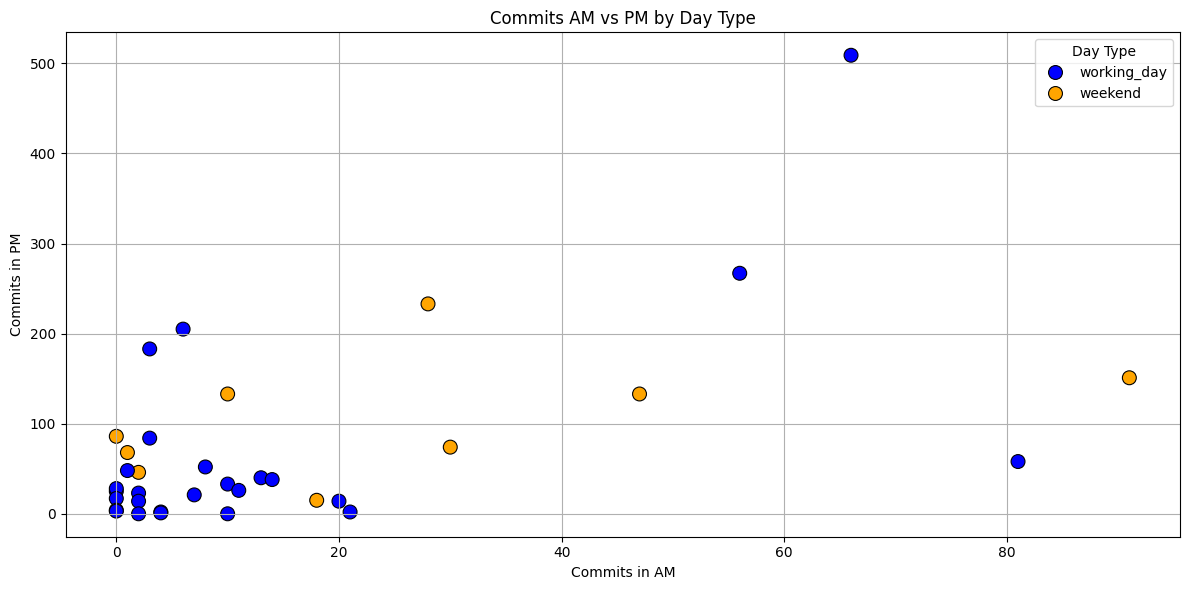

In [7]:
plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=df,
    x='AM',
    y='PM',
    hue='target',
    palette={'working_day': 'blue', 'weekend': 'orange'},
    s=100, 
    edgecolor='black'
)

plt.title('Commits AM vs PM by Day Type')
plt.xlabel('Commits in AM')
plt.ylabel('Commits in PM')
plt.grid(True)
plt.legend(title='Day Type')
plt.tight_layout()
plt.show()

Да, просто

## 3. Логистическая регрессия

- Обучи модель логистической регрессии на своих данных, используя `am` и `pm`; параметры: `random state=21`, `fit_intercept=False`.  

- Сделай предсказания для каждого дня из набора данных и добавь их в датафрейм в столбец с именем `predict`.  

- Сохрани датафрейм в файл в подпапке дня `data` под именем `am_pm.csv`.  

- Построй ещё один график, как ранее, но теперь цвет точек должен определяться значениями из столбца `predict`.  

- Посмотрев на график, как ты думаешь, сделала ли модель хорошие предсказания? Напиши свой ответ в markdown-ячейке в конце этого раздела: "Да, хорошие"; "Нет, плохие".

In [8]:
x=df[['AM','PM']]
x

,AM,PM
0,21,2
1,1,68
2,18,15
3,2,23
4,0,25
5,0,28
6,10,33
7,2,14
8,30,74
9,28,233


In [9]:
le=LabelEncoder()
y=le.fit_transform(df['target'])
y

array([1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1,
       0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1])

In [10]:
model = LogisticRegression( random_state=21 , fit_intercept=False )

model.fit(x,y)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",False
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",21
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mult

In [11]:
y_pred = model.predict(x)
y_text = le.inverse_transform(y_pred)
y_text

array(['weekend', 'working_day', 'working_day', 'working_day',
       'working_day', 'working_day', 'working_day', 'working_day',
       'working_day', 'working_day', 'working_day', 'working_day',
       'working_day', 'working_day', 'working_day', 'working_day',
       'working_day', 'working_day', 'working_day', 'weekend',
       'working_day', 'working_day', 'working_day', 'working_day',
       'working_day', 'working_day', 'working_day', 'working_day',
       'weekend', 'working_day', 'working_day', 'working_day',
       'working_day', 'working_day', 'working_day'], dtype=object)

In [12]:
df['predict']=y_text
df = df.rename(columns={'AM': 'am', 'PM': 'pm'})
df=df[['date','am','pm','target','predict']]
df['target'] = df['target'].astype('object')
df

,date,am,pm,target,predict
0,2020-04-17,21,2,working_day,weekend
1,2020-04-18,1,68,weekend,working_day
2,2020-04-19,18,15,weekend,working_day
3,2020-04-20,2,23,working_day,working_day
4,2020-04-21,0,25,working_day,working_day
5,2020-04-22,0,28,working_day,working_day
6,2020-04-23,10,33,working_day,working_day
7,2020-04-24,2,14,working_day,working_day
8,2020-04-25,30,74,weekend,working_day
9,2020-04-26,28,233,weekend,working_day


In [13]:
df.to_csv('../data/am_pm.csv')

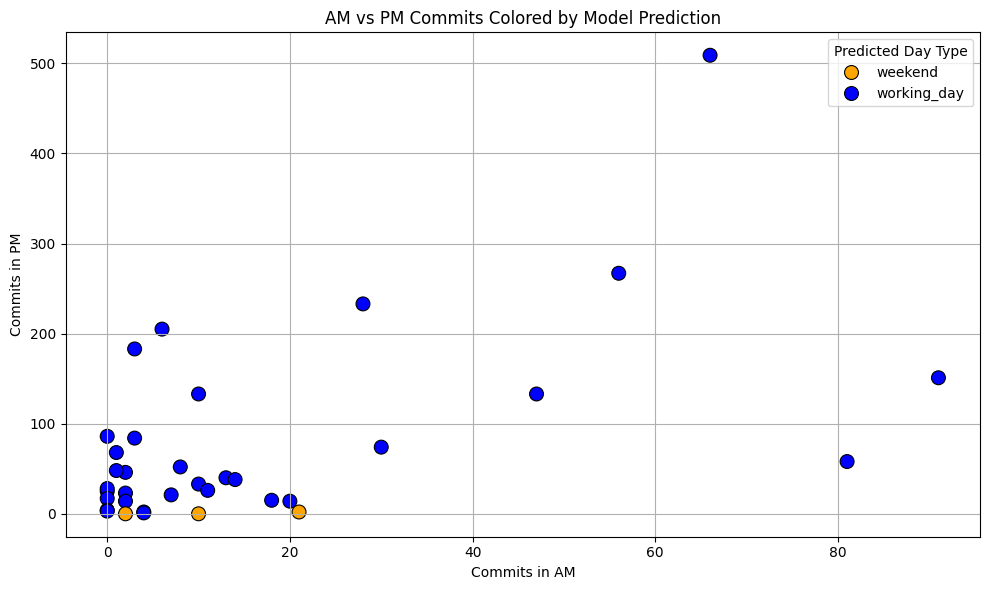

In [14]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x='am',
    y='pm',
    hue='predict',
    palette={'working_day': 'blue', 'weekend': 'orange'},
    s=100,
    edgecolor='black'
)

plt.title('AM vs PM Commits Colored by Model Prediction')
plt.xlabel('Commits in AM')
plt.ylabel('Commits in PM')
plt.grid(True)
plt.legend(title='Predicted Day Type')
plt.tight_layout()
plt.show()

Нет, не просто

## 4. Оценка

- Вычисли `accuracy` (точность) для своих предсказаний.  

- Вычисли `accuracy` для наивного случая, когда каждое предсказание — это значение самого популярного класса дня.  

- Сравни значения точности и подумай, сделал ли классификатор хорошие предсказания? Напиши свой ответ в markdown-ячейке в конце этого раздела: "Да, хорошие"; "Нет, плохие".

In [15]:
accuracy_model = accuracy_score(df['target'], df['predict'])
print(f'Accuracy of the model: {accuracy_model }')

Accuracy of the model: 0.6285714285714286


In [16]:
most_common = df['target'].value_counts().idxmax()
naive_predictions = [most_common] * len(df)
naive_accuracy = accuracy_score(df['target'], naive_predictions)
print(f'Accuracy of the native model: {naive_accuracy }')

Accuracy of the native model: 0.7142857142857143


Нет, плохие

In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 35 entries, 0 to 34
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   date     35 non-null     object
 1   am       35 non-null     int64 
 2   pm       35 non-null     int64 
 3   target   35 non-null     object
 4   predict  35 non-null     str   
dtypes: int64(2), object(2), str(1)
memory usage: 1.5+ KB
